In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Q-function and Complementary Error Function (erfc)

The Q-function is defined as

$$Q(x) = \frac{1}{\sqrt{2\pi}} \int_x^{\infty} e^{-t^2/2} \, dt
$$

The complementary error function is defined as

$$\operatorname{erfc}(x) = \frac{2}{\sqrt{\pi}} \int_x^{\infty} e^{-t^2} \, dt
$$

We can show that the Q-function is related to the complementary error function by:

$$
Q(x) = \frac{1}{2} \operatorname{erfc}\!\left(\frac{x}{\sqrt{2}}\right)
$$


In [67]:
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))

## Rayleigh Flat Fading Model

Many small scattered paths → Complex circular symmetric Gaussian.

$$
h_\ell[m] \sim \mathcal{N}\!\left(0,\frac{\sigma^2}{2}\right) 
+ i\,\mathcal{N}\!\left(0,\frac{\sigma^2}{2}\right)
\sim \mathcal{CN}(0,\sigma^2)
$$

For normalized unit average power case:

$$
h \sim \mathcal{CN}(0,1)
$$

---

### Fact: Distribution of $|h|$

$$
p_{|h|}(r) = \frac{2r}{\sigma^2} \exp\!\left(-\frac{r^2}{\sigma^2}\right),
\qquad r > 0
$$

---

### Fact: Distribution of $|h|^2$

$$
p_{|h|^2}(r) = \frac{1}{\sigma^2} \exp\!\left(-\frac{r}{\sigma^2}\right),
\qquad r > 0
$$


In [70]:
def RayleighChannel(N_bits):
    return (np.random.randn(N_bits)+1j*np.random.randn(N_bits))/np.sqrt(2);

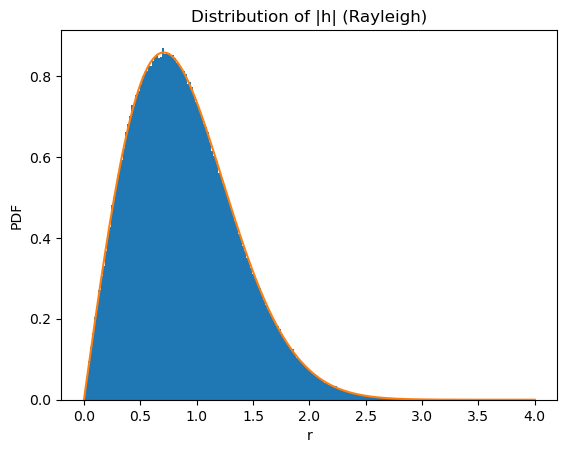

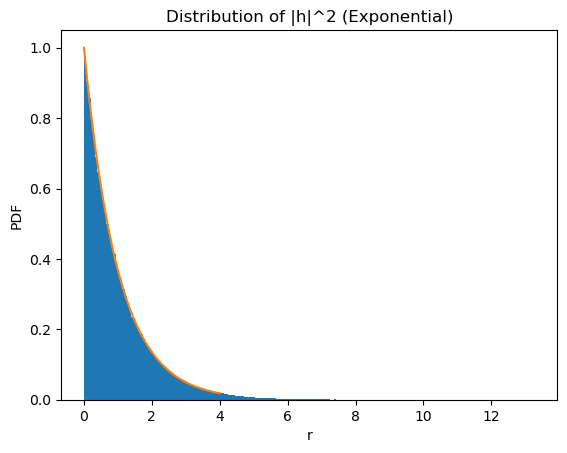

In [117]:
# Generate Rayleigh fading samples: h ~ CN(0,1)
import matplotlib.pyplot as plt
N = 1_000_000
h =  RayleighChannel(N)

# Magnitude and magnitude squared
r = np.abs(h)
r2 = np.abs(h)**2

# -----------------------------
# Plot |h|  (Rayleigh)
# -----------------------------
plt.figure()
count, bins, _ = plt.hist(r, bins=200, density=True)

# Theoretical Rayleigh PDF (sigma^2 = 1 → sigma = 1/sqrt(2))
sigma2 = 1
x = np.linspace(0, 4, 1000)
rayleigh_pdf = 2*x/sigma2 * np.exp(-x**2/sigma2)

plt.plot(x, rayleigh_pdf)
plt.title("Distribution of |h| (Rayleigh)")
plt.xlabel("r")
plt.ylabel("PDF")
plt.show()

# -----------------------------
# Plot |h|^2 (Exponential)
# -----------------------------
plt.figure()
count2, bins2, _ = plt.hist(r2, bins=200, density=True)

# Theoretical exponential PDF
exp_pdf = (1/sigma2) * np.exp(-x/sigma2)

plt.plot(x, exp_pdf)
plt.title("Distribution of |h|^2 (Exponential)")
plt.xlabel("r")
plt.ylabel("PDF")
plt.show()


In [119]:
# ============================
# Parameters
# ============================
N_bits = 10**6             # Number of bits to simulate
EbN0_dB = np.arange(0, 21, 2)  # SNR range in dB
print (EbN0_dB)

[ 0  2  4  6  8 10 12 14 16 18 20]


In [127]:
x= np.random.randint(0, 2, N_bits)
print (x)

[1 1 0 ... 1 0 0]


In [131]:
def bpsk_mod(bits):
    return (2*bits - 1)

y=bpsk_mod(x)
print (y)

[ 1  1 -1 ...  1 -1 -1]


In [133]:
def bpsk_demod(received):
    return (received >= 0).astype(int)

rec=bpsk_demod(y)
print (rec)
    

[1 1 0 ... 1 0 0]


In [135]:
def awgn_sim(N_bits, EbN0_dB):
        EbN0_linear = 10**(EbN0_dB/10)
        noise_std = np.sqrt(1/(2*EbN0_linear))
        n = noise_std * np.random.randn(N_bits)
        return n

## Explanation of AWGN Noise Generation Code

We consider the function:

def ber_awgn_sim(N_bits, EbN0_dB):
    EbN0_linear = 10**(EbN0_dB/10)
    noise_std = np.sqrt(1/(2*EbN0_linear))
    n = noise_std * np.random.randn(N_bits)
    return n

This function generates Additive White Gaussian Noise (AWGN) samples
for a given $E_b/N_0$ value.

---

### Step 1: Convert $E_b/N_0$ from dB to Linear Scale

Noise calculations must be done in linear scale.

$$
\left(\frac{E_b}{N_0}\right)_{\text{linear}}
=
10^{\frac{E_b/N_0\;(\text{dB})}{10}}
$$

This is implemented as:

EbN0_linear = 10**(EbN0_dB/10)

---

### Step 2: Compute Noise Variance

For BPSK with unit bit energy ($E_b = 1$):

$$
\sigma^2 = \frac{N_0}{2}
$$

Since

$$
\frac{E_b}{N_0} = \frac{1}{N_0}
\quad \Rightarrow \quad
N_0 = \frac{1}{E_b/N_0}
$$

we obtain

$$
\sigma^2 = \frac{1}{2(E_b/N_0)}
$$

The standard deviation is therefore

$$
\sigma = \sqrt{\frac{1}{2(E_b/N_0)}}
$$

This is implemented as:

noise_std = np.sqrt(1/(2*EbN0_linear))

---

### Step 3: Generate Gaussian Noise Samples

np.random.randn(N_bits) generates samples from:

$$
\mathcal{N}(0,1)
$$

Multiplying by noise_std scales the variance:

$$
n \sim \mathcal{N}(0, \sigma^2)
$$

This is implemented as:

n = noise_std * np.random.randn(N_bits)

---

### Step 4: Return the Noise Vector

The function returns:

$$
n \sim \mathcal{N}\left(0, \frac{1}{2(E_b/N_0)}\right)
$$

This noise vector can be added to a BPSK signal to simulate AWGN channel effects.



## Rayleigh Channel and BER for BPSK

### Channel Model

$$
y = h x + w
$$

where

$$
h \sim \mathcal{CN}(0,1)
$$

and BPSK modulation:

$$
x \in \{ +a, -a \}
$$

---

### Conditional Error Probability (given $h$)

For a fixed channel realization $h$, the conditional bit error probability is

$$
p_e \mid h
=
Q\!\left(\sqrt{2 |h|^2 \, \mathrm{SNR}}\right)
$$

---

### Averaging Over Rayleigh Fading

Since

$$
|h|^2 \sim \text{Exponential}(1)
$$

the average error probability becomes

$$
p_e
=
\int_{0}^{\infty}
Q\!\left(\sqrt{2 x \, \mathrm{SNR}}\right)
e^{-x} \, dx
$$

This integral evaluates to

$$
p_e
=
\frac{1}{2}
\left(
1 -
\sqrt{\frac{\mathrm{SNR}}{\mathrm{SNR}+1}}
\right)
$$

---

### High-SNR Approximation

For large SNR,

$$
p_e
\approx
\frac{1}{4\,\mathrm{SNR}}
$$


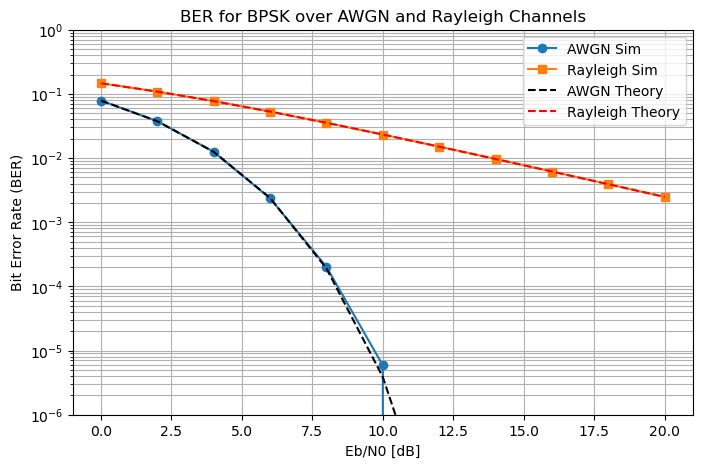

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# ----------------------------
# Helpers: Q-function
# ----------------------------
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))

# ----------------------------
# Parameters
# ----------------------------
N_bits = 10**7
EbN0_dB = np.arange(0, 21, 2)   # 0 to 20 dB in steps of 2 dB (edit as you like)

# ----------------------------
# Channel + Mod/Demod
# ----------------------------
def RayleighChannel(N_bits):
    # h ~ CN(0,1)
    return (np.random.randn(N_bits) + 1j*np.random.randn(N_bits)) / np.sqrt(2)

def bpsk_mod(bits):
    # 0 -> -1, 1 -> +1
    return 2*bits - 1

def bpsk_demod(received_real):
    # hard decision for BPSK
    return (received_real >= 0).astype(int)

def awgn_sim_real(N_bits, EbN0_dB):
    # real AWGN for real-valued AWGN channel
    EbN0_linear = 10**(EbN0_dB/10)
    noise_std = np.sqrt(1/(2*EbN0_linear))
    return noise_std * np.random.randn(N_bits)

def awgn_sim_complex(N_bits, EbN0_dB):
    # complex AWGN: n ~ CN(0, N0), with per-dimension std sqrt(N0/2)
    EbN0_linear = 10**(EbN0_dB/10)
    noise_std = np.sqrt(1/(2*EbN0_linear))
    return noise_std * (np.random.randn(N_bits) + 1j*np.random.randn(N_bits))

# ----------------------------
# AWGN Channel Simulation
# ----------------------------
def ber_awgn_sim(N_bits, EbN0_dB_vec):
    ber = []
    bits = np.random.randint(0, 2, N_bits)
    s = bpsk_mod(bits)

    for EbN0 in EbN0_dB_vec:
        n = awgn_sim_real(N_bits, EbN0)
        r = s + n
        bits_hat = bpsk_demod(r)  # r is real
        ber.append(np.mean(bits != bits_hat))

    return np.array(ber)

# ----------------------------
# Rayleigh Channel Simulation (corrected)
# ----------------------------
def ber_rayleigh_sim(N_bits, EbN0_dB_vec):
    ber = []
    bits = np.random.randint(0, 2, N_bits)
    s = bpsk_mod(bits)

    for EbN0 in EbN0_dB_vec:
        h = RayleighChannel(N_bits)
        n = awgn_sim_complex(N_bits, EbN0)     # IMPORTANT: complex noise
        r = h*s + n

        # Coherent equalization: conj(h)/|h|^2
        r_eq = np.real(np.conj(h) * r) / (np.abs(h)**2 + 1e-12)

        bits_hat = bpsk_demod(r_eq)
        ber.append(np.mean(bits != bits_hat))

    return np.array(ber)

# ----------------------------
# Analytical BER
# ----------------------------
def ber_awgn_theory(EbN0_dB):
    EbN0_linear = 10**(EbN0_dB/10)
    return qfunc(np.sqrt(2*EbN0_linear))

def ber_rayleigh_theory(EbN0_dB):
    EbN0_linear = 10**(EbN0_dB/10)
    return 0.5 * (1 - np.sqrt(EbN0_linear/(EbN0_linear + 1)))

# ----------------------------
# Run simulations
# ----------------------------
ber_awgn = ber_awgn_sim(N_bits, EbN0_dB)
ber_rayleigh = ber_rayleigh_sim(N_bits, EbN0_dB)

# ----------------------------
# Plot results
# ----------------------------
plt.figure(figsize=(8,5))
plt.semilogy(EbN0_dB, ber_awgn, 'o-', label='AWGN Sim')
plt.semilogy(EbN0_dB, ber_rayleigh, 's-', label='Rayleigh Sim')
plt.semilogy(EbN0_dB, ber_awgn_theory(EbN0_dB), 'k--', label='AWGN Theory')
plt.semilogy(EbN0_dB, ber_rayleigh_theory(EbN0_dB), 'r--', label='Rayleigh Theory')
plt.grid(True, which='both')
plt.xlabel('Eb/N0 [dB]')
plt.ylabel('Bit Error Rate (BER)')
plt.title('BER for BPSK over AWGN and Rayleigh Channels')
plt.ylim(1e-6, 1)
plt.legend()
plt.show()


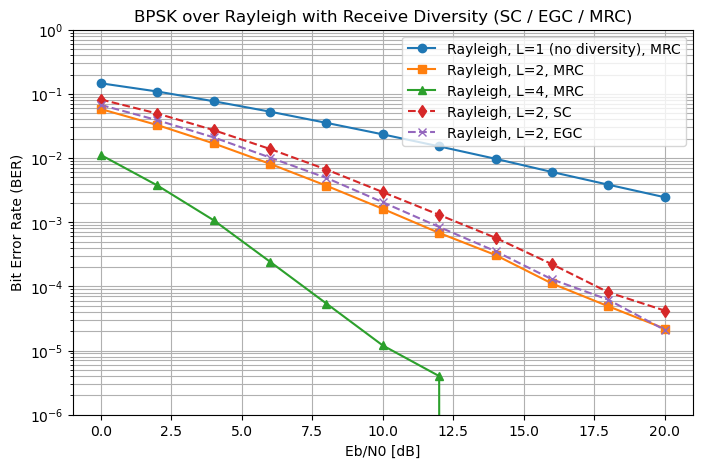

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# ----------------------------
# Q-function
# ----------------------------
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))

# ----------------------------
# Parameters
# ----------------------------
N_bits = 10**6
EbN0_dB = np.arange(0, 21, 2)   # edit as needed

# ----------------------------
# Mod/Demod
# ----------------------------
def bpsk_mod(bits):
    return 2*bits - 1  # 0->-1, 1->+1

def bpsk_demod(x_real):
    return (x_real >= 0).astype(int)

# ----------------------------
# Fading + Noise
# ----------------------------
def rayleigh_h(shape):
    # CN(0,1)
    return (np.random.randn(*shape) + 1j*np.random.randn(*shape)) / np.sqrt(2)

def awgn_complex(shape, EbN0_dB):
    EbN0 = 10**(EbN0_dB/10)
    noise_std = np.sqrt(1/(2*EbN0))  # per real dimension
    return noise_std * (np.random.randn(*shape) + 1j*np.random.randn(*shape))

# ----------------------------
# Diversity Simulation (L-branch)
# - SIMO receive diversity
# - Coherent combining
#   * SC:  selection combining
#   * EGC: equal-gain combining
#   * MRC: maximal-ratio combining
# ----------------------------
def ber_rayleigh_diversity_sim(N_bits, EbN0_dB_vec, L=2, combining="MRC"):
    ber = []
    bits = np.random.randint(0, 2, N_bits)
    s = bpsk_mod(bits).astype(float)  # real ±1

    for snr_db in EbN0_dB_vec:
        # h and noise for each branch: shape (L, N_bits)
        h = rayleigh_h((L, N_bits))
        n = awgn_complex((L, N_bits), snr_db)

        # received on each branch
        r = h * s + n  # broadcasting s across L

        combining_u = combining.upper()

        if combining_u == "MRC":
            # z = sum_k h*_k r_k  => decision on Re(z)
            z = np.sum(np.conj(h) * r, axis=0)

        elif combining_u == "EGC":
            # phase-only alignment then sum: z = sum_k (h*_k/|h_k|) r_k
            w = np.conj(h) / (np.abs(h) + 1e-12)
            z = np.sum(w * r, axis=0)

        elif combining_u == "SC":
            # pick branch with max |h|^2 and equalize that branch only
            idx = np.argmax(np.abs(h)**2, axis=0)  # length N_bits
            r_sel = r[idx, np.arange(N_bits)]
            h_sel = h[idx, np.arange(N_bits)]
            z = np.conj(h_sel) * r_sel  # phase-aligned (no need /|h|^2 for sign)

        else:
            raise ValueError("combining must be one of: 'MRC', 'EGC', 'SC'")

        bits_hat = bpsk_demod(np.real(z))
        ber.append(np.mean(bits != bits_hat))

    return np.array(ber)

# ----------------------------
# Run: compare L = 1,2,4 with MRC
# ----------------------------
ber_L1 = ber_rayleigh_diversity_sim(N_bits, EbN0_dB, L=1, combining="MRC")
ber_L2 = ber_rayleigh_diversity_sim(N_bits, EbN0_dB, L=2, combining="MRC")
ber_L4 = ber_rayleigh_diversity_sim(N_bits, EbN0_dB, L=4, combining="MRC")

# Optional: compare combining methods for L=2
ber_L2_sc  = ber_rayleigh_diversity_sim(N_bits, EbN0_dB, L=2, combining="SC")
ber_L2_egc = ber_rayleigh_diversity_sim(N_bits, EbN0_dB, L=2, combining="EGC")

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.semilogy(EbN0_dB, ber_L1, 'o-', label='Rayleigh, L=1 (no diversity), MRC')
plt.semilogy(EbN0_dB, ber_L2, 's-', label='Rayleigh, L=2, MRC')
plt.semilogy(EbN0_dB, ber_L4, '^-', label='Rayleigh, L=4, MRC')

plt.semilogy(EbN0_dB, ber_L2_sc,  'd--', label='Rayleigh, L=2, SC')
plt.semilogy(EbN0_dB, ber_L2_egc, 'x--', label='Rayleigh, L=2, EGC')

plt.grid(True, which='both')
plt.xlabel('Eb/N0 [dB]')
plt.ylabel('Bit Error Rate (BER)')
plt.title('BPSK over Rayleigh with Receive Diversity (SC / EGC / MRC)')
plt.ylim(1e-6, 1)
plt.legend()
plt.show()
